# Phase1-FeatureExtraction

 Install and Import Libraries

In [68]:
# ── install libraries not pre-installed on Kaggle ──────────────────
!pip install transformers librosa --quiet

# ── standard library ───────────────────────────────────────────────
import os
import random
import warnings
warnings.filterwarnings('ignore')

# ── numerical & data handling ──────────────────────────────────────
import numpy as np
import pandas as pd

# ── audio loading ──────────────────────────────────────────────────
import librosa

# ── deep learning ──────────────────────────────────────────────────
import torch

# ── HuggingFace models & processors ───────────────────────────────
from transformers import (
    Wav2Vec2Model,
    Wav2Vec2Processor,
    HubertModel,
    Wav2Vec2FeatureExtractor,
)

# ── progress bar ───────────────────────────────────────────────────
from tqdm import tqdm

print("All libraries imported successfully")

All libraries imported successfully


Reproducibility

In [69]:
# ── fix all random seeds ────────────────────────────────────────────

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f"Random seed set to {SEED}")

Random seed set to 42


Configuration Block

In [70]:
# ── dataset identity ───────────────────────────────────────────────
DATASET_NAME   = "SAVEE"
NUM_CLASSES    = 7
DATASET_PATH   = "/kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee"
OUTPUT_PATH    = "/kaggle/working/"
SAMPLE_RATE    = 16000
HUBERT_MODEL   = "facebook/hubert-large-ls960-ft"
WAV2VEC_MODEL  = "facebook/wav2vec2-large-960h"
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
HUBERT_OUT     = f"{OUTPUT_PATH}ser_{DATASET_NAME.lower()}_hubert_vectors.npz"
WAV2VEC_OUT    = f"{OUTPUT_PATH}ser_{DATASET_NAME.lower()}_wav2vec2_vectors.npz"

print(f"Dataset      : {DATASET_NAME}")
print(f"Num classes  : {NUM_CLASSES}")
print(f"Device       : {DEVICE}")
print(f"HuBERT model : {HUBERT_MODEL}")
print(f"Wav2Vec2     : {WAV2VEC_MODEL}")

Dataset      : SAVEE
Num classes  : 7
Device       : cuda
HuBERT model : facebook/hubert-large-ls960-ft
Wav2Vec2     : facebook/wav2vec2-large-960h


In [71]:
import kagglehub

path = kagglehub.dataset_download("ejlok1/surrey-audiovisual-expressed-emotion-savee")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee


In [72]:
# ── step 1: see the top-level folder structure ─────────────────────
print("=== TOP LEVEL ===")
for item in os.listdir(DATASET_PATH):
    print(f"  {item}")

# ── step 2: walk all subfolders and count wav files ────────────────
print("\n=== ALL WAV FILES FOUND ===")
all_wavs = []
for root, dirs, files in os.walk(DATASET_PATH):
    for f in files:
        if f.endswith('.wav') or f.endswith('.WAV'):
            all_wavs.append(os.path.join(root, f))

print(f"Total wav files found: {len(all_wavs)}")

# ── step 3: print first 20 filenames so we see the naming pattern ──
print("\n=== FIRST 20 FILENAMES ===")
for path in all_wavs[:20]:
    print(f"  {path}")

# ── step 4: print folder names (may encode emotion) ────────────────
print("\n=== ALL SUBFOLDERS ===")
for root, dirs, files in os.walk(DATASET_PATH):
    if dirs:
        for d in dirs:
            print(f"  {os.path.join(root, d)}")

=== TOP LEVEL ===
  ALL

=== ALL WAV FILES FOUND ===
Total wav files found: 480

=== FIRST 20 FILENAMES ===
  /kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee/ALL/JE_h09.wav
  /kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee/ALL/KL_f12.wav
  /kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee/ALL/DC_h03.wav
  /kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee/ALL/DC_d04.wav
  /kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee/ALL/KL_a14.wav
  /kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee/ALL/JE_f01.wav
  /kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee/ALL/KL_h15.wav
  /kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee/ALL/JK_su02.wav
  /kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee/ALL/JK_a06.wav
  /kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee/ALL/DC

Dataset Loading and Label Preparation

In [73]:
# ── SAVEE emotion prefix mapping ───────────────────────────────────

EMOTION_MAP = {
    'a'  : 'anger',
    'd'  : 'disgust',
    'f'  : 'fear',
    'h'  : 'happiness',
    'n'  : 'neutral',
    'sa' : 'sadness',
    'su' : 'surprise',
}

file_paths = []
labels     = []

for root, dirs, files in os.walk(DATASET_PATH):
    for fname in files:
        if not fname.endswith('.wav'):
            continue

        # extract the emotion code from the filename
        
        code_raw = fname.split('_')[-1].replace('.wav', '')
        code     = ''.join([c for c in code_raw if not c.isdigit()])

        if code in EMOTION_MAP:
            file_paths.append(os.path.join(root, fname))
            labels.append(EMOTION_MAP[code])

# ── build dataframe ────────────────────────────────────────────────
df = pd.DataFrame({'path': file_paths, 'emotion': labels})

# ── encode labels as integers ──────────────────────────────────────
LABEL2ID = {label: idx for idx, label in enumerate(sorted(df['emotion'].unique()))}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
df['label'] = df['emotion'].map(LABEL2ID)

print(f"Total samples : {len(df)}")
print(f"Label mapping : {LABEL2ID}")
print(f"\nClass distribution:")
print(df['emotion'].value_counts())

Total samples : 480
Label mapping : {'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'neutral': 4, 'sadness': 5, 'surprise': 6}

Class distribution:
emotion
neutral      120
fear          60
happiness     60
disgust       60
anger         60
surprise      60
sadness       60
Name: count, dtype: int64


Audio Preprocessing Verification

In [74]:
# ── define a loading function used throughout the notebook ─────────

def load_audio(path, target_sr=SAMPLE_RATE):
    waveform, sr = librosa.load(path, sr=target_sr, mono=True)
    return waveform  # numpy array, shape (T,)

# ── verify a sample of files load correctly ────────────────────────
errors = []
for path in df['path'].values:
    try:
        w = load_audio(path)
        assert len(w) > 0
    except Exception as e:
        errors.append((path, str(e)))

if errors:
    print(f"WARNING: {len(errors)} files failed to load:")
    for p, err in errors:
        print(f"  {p} → {err}")
else:
    print(f"All {len(df)} files verified — no loading errors")
    print(f"All files resampled to {SAMPLE_RATE} Hz")

All 480 files verified — no loading errors
All files resampled to 16000 Hz


Model Loading

In [75]:
# ── HuBERT large  ───────────────────────────────────────
print("Loading HuBERT large...")
hubert_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_MODEL)
hubert_model     = HubertModel.from_pretrained(HUBERT_MODEL)
hubert_model.to(DEVICE)
hubert_model.eval()
for param in hubert_model.parameters():
    param.requires_grad = False
print("HuBERT large loaded and frozen")

# ── Wav2Vec2 large lv60  ─────────────────────
print("Loading Wav2Vec2 large lv60...")
wav2vec_processor = Wav2Vec2FeatureExtractor.from_pretrained(WAV2VEC_MODEL)
wav2vec_model     = Wav2Vec2Model.from_pretrained(WAV2VEC_MODEL)
wav2vec_model.to(DEVICE)
wav2vec_model.eval()
for param in wav2vec_model.parameters():
    param.requires_grad = False
print("Wav2Vec2 large lv60 loaded and frozen")

print(f"\nBoth models on device: {DEVICE}")

Loading HuBERT large...


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HuBERT large loaded and frozen
Loading Wav2Vec2 large lv60...


Loading weights:   0%|          | 0/402 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-large-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2 large lv60 loaded and frozen

Both models on device: cuda


Feature Extraction

In [79]:
def extract_features(model, processor, path, layer_start=0, layer_end=None):
    waveform = load_audio(path)
    inputs   = processor(
        waveform,
        sampling_rate  = SAMPLE_RATE,
        return_tensors = "pt",
        padding        = True,
    )
    input_values = inputs.input_values.to(DEVICE)
    with torch.no_grad():
        outputs = model(
            input_values,
            output_hidden_states = True,
        )
    all_layers  = torch.stack(outputs.hidden_states, dim=0)
    all_layers  = all_layers.squeeze(1)
    sel_layers  = all_layers[layer_start:layer_end]
    mean_layers = sel_layers.mean(dim=0)
    vector      = mean_layers.mean(dim=0).cpu().numpy()
    return vector


# ── HuBERT — all layers ────────────────────────────────────────────
print("Extracting HuBERT features (all layers)...")
hubert_vectors = []
for path in tqdm(df['path'].values):
    vec = extract_features(hubert_model, hubert_extractor, path,
                            layer_start=0, layer_end=None)
    hubert_vectors.append(vec)
hubert_vectors = np.array(hubert_vectors)
print(f"HuBERT vectors shape  : {hubert_vectors.shape}")

# ── Wav2Vec2 — all layers ──────────────────────────────────────────
print("Extracting Wav2Vec2 features (all layers)...")
wav2vec_vectors = []
for path in tqdm(df['path'].values):
    vec = extract_features(wav2vec_model, wav2vec_processor, path,
                            layer_start=0, layer_end=None)
    wav2vec_vectors.append(vec)
wav2vec_vectors = np.array(wav2vec_vectors)
print(f"Wav2Vec2 vectors shape: {wav2vec_vectors.shape}")

labels_array = df['label'].values
print(f"Labels shape          : {labels_array.shape}")


Extracting HuBERT features (all layers)...


100%|██████████| 480/480 [00:30<00:00, 15.99it/s]


HuBERT vectors shape  : (480, 1024)
Extracting Wav2Vec2 features (all layers)...


100%|██████████| 480/480 [00:29<00:00, 16.20it/s]

Wav2Vec2 vectors shape: (480, 1024)
Labels shape          : (480,)


Saving the Extracted Vectors

In [81]:
# ── save HuBERT vectors + labels ───────────────────────────────────
np.savez(
    HUBERT_OUT,
    vectors  = hubert_vectors,
    labels   = labels_array,
    id2label = str(ID2LABEL),
)
print(f"HuBERT vectors saved  → {HUBERT_OUT}")

np.savez(
    WAV2VEC_OUT,
    vectors  = wav2vec_vectors,
    labels   = labels_array,
    id2label = str(ID2LABEL),
)
print(f"Wav2Vec2 vectors saved → {WAV2VEC_OUT}")

HuBERT vectors saved  → /kaggle/working/ser_savee_hubert_vectors.npz
Wav2Vec2 vectors saved → /kaggle/working/ser_savee_wav2vec2_vectors.npz


 Verification

In [82]:
# ── reload saved files and verify integrity ────────────────────────
hubert_check  = np.load(HUBERT_OUT,  allow_pickle=True)
wav2vec_check = np.load(WAV2VEC_OUT, allow_pickle=True)

print("=== HuBERT ===")
print(f"  vectors shape : {hubert_check['vectors'].shape}")
print(f"  labels shape  : {hubert_check['labels'].shape}")
print(f"  unique labels : {np.unique(hubert_check['labels'])}")

print("\n=== Wav2Vec2 ===")
print(f"  vectors shape : {wav2vec_check['vectors'].shape}")
print(f"  labels shape  : {wav2vec_check['labels'].shape}")
print(f"  unique labels : {np.unique(wav2vec_check['labels'])}")

print("\n✓ Vectors verified — ready for Phase 2")

=== HuBERT ===
  vectors shape : (480, 1024)
  labels shape  : (480,)
  unique labels : [0 1 2 3 4 5 6]

=== Wav2Vec2 ===
  vectors shape : (480, 1024)
  labels shape  : (480,)
  unique labels : [0 1 2 3 4 5 6]

✓ Vectors verified — ready for Phase 2


# Phase 2: Classification

configuration

In [83]:
FEATURE_DIM       = 1024
N_FOLDS           = 5
N_EPOCHS          = 500
BATCH_SIZE        = 16
LEARNING_RATE     = 5e-4
HIDDEN_DIM        = 512
DROPOUT           = 0.5    # strong dropout prevents memorization
WEIGHT_DECAY      = 1e-3   # stronger L2 regularization
PATIENCE          = 50     # back to training loss early stopping
USE_CLASS_WEIGHTS = True
NORMALIZE         = True

print(f"Feature dim  : {FEATURE_DIM}")
print(f"Epochs       : {N_EPOCHS}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Hidden dim   : {HIDDEN_DIM}")
print(f"Dropout      : {DROPOUT}")
print(f"Weight decay : {WEIGHT_DECAY}")

Feature dim  : 1024
Epochs       : 500
Batch size   : 16
Learning rate: 0.0005
Hidden dim   : 512
Dropout      : 0.5
Weight decay : 0.001


Imports

In [84]:
import torch.nn as nn
from torch.utils.data   import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics   import accuracy_score, balanced_accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Phase 2 imports done")

Phase 2 imports done


classification model (two feed-forward layers as in the paper)

In [85]:
class EmotionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

print("EmotionClassifier defined")
print(f"  Architecture: Linear({FEATURE_DIM}→{HIDDEN_DIM}) → BN → ReLU → Dropout → Linear({HIDDEN_DIM}→{NUM_CLASSES})")

EmotionClassifier defined
  Architecture: Linear(1024→512) → BN → ReLU → Dropout → Linear(512→7)


training and evaluation functions

In [87]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    all_preds  = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            preds   = model(X_batch).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_preds), np.array(all_labels)


def compute_metrics(preds, labels):
    wa  = accuracy_score(labels, preds) * 100
    ua  = balanced_accuracy_score(labels, preds) * 100
    cm  = confusion_matrix(labels, preds)
    return wa, ua, cm

print("Functions defined")

Functions defined


5-fold cross-validation function

In [88]:
from sklearn.preprocessing import StandardScaler

def run_kfold(X, y, model_name):
    skf = StratifiedKFold(
        n_splits     = N_FOLDS,
        shuffle      = True,
        random_state = SEED,
    )

    fold_wa       = []
    fold_ua       = []
    all_preds     = []
    all_labels    = []
    history       = []   # stores per-fold training curves

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        # ── normalize ──────────────────────────────────────────────────
        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X[train_idx])
        X_test  = scaler.transform(X[test_idx])
        y_train = y[train_idx]
        y_test  = y[test_idx]

        # ── class weights ──────────────────────────────────────────────
        if USE_CLASS_WEIGHTS:
            counts  = np.bincount(y_train, minlength=NUM_CLASSES)
            weights = 1.0 / (counts.astype(np.float32) + 1e-6)
            weights = weights / weights.sum() * NUM_CLASSES
            weights = torch.tensor(weights).to(DEVICE)
        else:
            weights = None

        # ── dataloaders ────────────────────────────────────────────────
        train_loader = DataLoader(
            TensorDataset(
                torch.tensor(X_train, dtype=torch.float32),
                torch.tensor(y_train, dtype=torch.long),
            ),
            batch_size=BATCH_SIZE, shuffle=True,
        )
        test_loader = DataLoader(
            TensorDataset(
                torch.tensor(X_test,  dtype=torch.float32),
                torch.tensor(y_test,  dtype=torch.long),
            ),
            batch_size=BATCH_SIZE, shuffle=False,
        )

        # ── model ──────────────────────────────────────────────────────
        model = EmotionClassifier(
            input_dim   = FEATURE_DIM,
            hidden_dim  = HIDDEN_DIM,
            num_classes = NUM_CLASSES,
            dropout     = DROPOUT,
        ).to(DEVICE)

        criterion = nn.CrossEntropyLoss(weight=weights)
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr           = LEARNING_RATE,
            weight_decay = WEIGHT_DECAY,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=20,
            factor=0.5, min_lr=1e-6,
        )

        # ── training loop ──────────────────────────────────────────────
        best_loss    = float('inf')
        patience_ctr = 0
        best_state   = None
        fold_losses  = []   # track loss every epoch
        fold_was     = []   # track test WA every epoch

        for epoch in range(N_EPOCHS):
            loss = train_one_epoch(model, train_loader, criterion, optimizer)
            scheduler.step(loss)
            fold_losses.append(loss)

            # evaluate on test every 10 epochs to track WA curve
            if (epoch + 1) % 10 == 0:
                p, l = evaluate(model, test_loader)
                fold_was.append(accuracy_score(l, p) * 100)

            # stop if loss is below minimum threshold (prevent memorization)
            if loss < 0.01:
                break

            if loss < best_loss:
                best_loss    = loss
                patience_ctr = 0
                best_state   = {
                    k: v.clone()
                    for k, v in model.state_dict().items()
                }
            else:
                patience_ctr += 1
                if patience_ctr >= PATIENCE:
                    break

        # ── evaluate with best checkpoint ──────────────────────────────
        model.load_state_dict(best_state)
        preds, labels_fold = evaluate(model, test_loader)
        wa, ua, _          = compute_metrics(preds, labels_fold)

        fold_wa.append(wa)
        fold_ua.append(ua)
        all_preds.extend(preds)
        all_labels.extend(labels_fold)
        history.append({
            'fold'   : fold,
            'losses' : fold_losses,
            'was'    : fold_was,
            'epochs' : len(fold_losses),
        })

        print(f"  [{model_name}] Fold {fold}/{N_FOLDS} — WA: {wa:.2f}%  UA: {ua:.2f}%  "
              f"epochs: {len(fold_losses)}  best_loss: {best_loss:.4f}")

    # ── summary ────────────────────────────────────────────────────────
    mean_wa = np.mean(fold_wa)
    std_wa  = np.std(fold_wa)
    mean_ua = np.mean(fold_ua)
    std_ua  = np.std(fold_ua)
    agg_cm  = confusion_matrix(all_labels, all_preds)

    print(f"\n  [{model_name}] WA: {mean_wa:.2f} ± {std_wa:.2f}")
    print(f"  [{model_name}] UA: {mean_ua:.2f} ± {std_ua:.2f}")

    return {
        'model_name' : model_name,
        'fold_wa'    : fold_wa,
        'fold_ua'    : fold_ua,
        'mean_wa'    : mean_wa,
        'std_wa'     : std_wa,
        'mean_ua'    : mean_ua,
        'std_ua'     : std_ua,
        'agg_cm'     : agg_cm,
        'history'    : history,
    }

print("run_kfold defined")

run_kfold defined


 run 5-fold CV for both models

In [89]:
# ── HuBERT ─────────────────────────────────────────────────────────
print("="*55)
print("Running 5-fold CV — HuBERT large")
print("="*55)
results_hubert = run_kfold(hubert_vectors, labels_array, "HuBERT")

# ── Wav2Vec2 ───────────────────────────────────────────────────────
print("\n" + "="*55)
print("Running 5-fold CV — Wav2Vec2 large")
print("="*55)
results_wav2vec = run_kfold(wav2vec_vectors, labels_array, "Wav2Vec2")

Running 5-fold CV — HuBERT large
  [HuBERT] Fold 1/5 — WA: 85.42%  UA: 83.93%  epochs: 100  best_loss: 0.0103
  [HuBERT] Fold 2/5 — WA: 88.54%  UA: 87.50%  epochs: 85  best_loss: 0.0103
  [HuBERT] Fold 3/5 — WA: 86.46%  UA: 84.52%  epochs: 103  best_loss: 0.0122
  [HuBERT] Fold 4/5 — WA: 89.58%  UA: 88.69%  epochs: 87  best_loss: 0.0119
  [HuBERT] Fold 5/5 — WA: 92.71%  UA: 91.67%  epochs: 117  best_loss: 0.0114

  [HuBERT] WA: 88.54 ± 2.55
  [HuBERT] UA: 87.26 ± 2.83

Running 5-fold CV — Wav2Vec2 large
  [Wav2Vec2] Fold 1/5 — WA: 86.46%  UA: 85.12%  epochs: 42  best_loss: 0.0132
  [Wav2Vec2] Fold 2/5 — WA: 86.46%  UA: 84.52%  epochs: 41  best_loss: 0.0121
  [Wav2Vec2] Fold 3/5 — WA: 86.46%  UA: 84.52%  epochs: 62  best_loss: 0.0102
  [Wav2Vec2] Fold 4/5 — WA: 94.79%  UA: 94.05%  epochs: 66  best_loss: 0.0114
  [Wav2Vec2] Fold 5/5 — WA: 91.67%  UA: 90.48%  epochs: 67  best_loss: 0.0113

  [Wav2Vec2] WA: 89.17 ± 3.46
  [Wav2Vec2] UA: 87.74 ± 3.87


 results summary table

In [90]:
# ── summary table matching Table 1 format of the paper ────────────
summary = pd.DataFrame([
    {
        'Dataset'             : DATASET_NAME,
        'Model'               : 'HuBERT large',
        'Weighted Accuracy'   : f"{results_hubert['mean_wa']:.2f} ± {results_hubert['std_wa']:.2f}",
        'Unweighted Accuracy' : f"{results_hubert['mean_ua']:.2f} ± {results_hubert['std_ua']:.2f}",
    },
    {
        'Dataset'             : DATASET_NAME,
        'Model'               : 'Wav2Vec2 large',
        'Weighted Accuracy'   : f"{results_wav2vec['mean_wa']:.2f} ± {results_wav2vec['std_wa']:.2f}",
        'Unweighted Accuracy' : f"{results_wav2vec['mean_ua']:.2f} ± {results_wav2vec['std_ua']:.2f}",
    },
])

print("\n=== RESULTS — SAVEE ===")
print(summary.to_string(index=False))

# ── paper reference values for comparison ─────────────────────────
print("\n=== PAPER REFERENCE (Table 1) ===")
print("HuBERT   — WA: 91.66 ± 1.2   UA: 90.48 ± 1.1")
print("Wav2Vec2 — WA: 83.34 ± 1.3   UA: 80.95 ± 1.1")


=== RESULTS — SAVEE ===
Dataset          Model Weighted Accuracy Unweighted Accuracy
  SAVEE   HuBERT large      88.54 ± 2.55        87.26 ± 2.83
  SAVEE Wav2Vec2 large      89.17 ± 3.46        87.74 ± 3.87

=== PAPER REFERENCE (Table 1) ===
HuBERT   — WA: 91.66 ± 1.2   UA: 90.48 ± 1.1
Wav2Vec2 — WA: 83.34 ± 1.3   UA: 80.95 ± 1.1


 confusion matrices

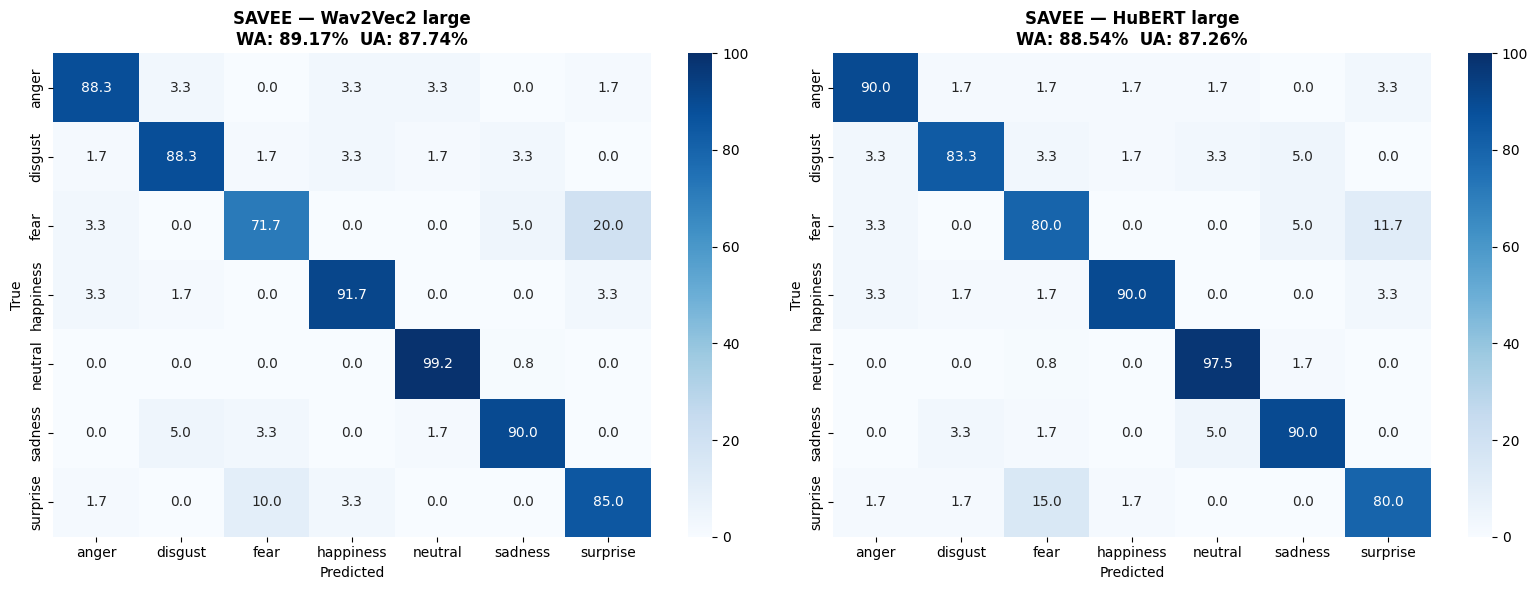

Confusion matrices saved


In [91]:
def plot_confusion_matrix(cm, class_names, title, ax):
    # normalize to percentage per row (per true class)
    cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(
        cm_pct,
        annot      = True,
        fmt        = '.1f',
        cmap       = 'Blues',
        xticklabels= class_names,
        yticklabels= class_names,
        ax         = ax,
        vmin       = 0,
        vmax       = 100,
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')


class_names = [ID2LABEL[i] for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_confusion_matrix(
    results_wav2vec['agg_cm'],
    class_names,
    f"SAVEE — Wav2Vec2 large\nWA: {results_wav2vec['mean_wa']:.2f}%  UA: {results_wav2vec['mean_ua']:.2f}%",
    axes[0],
)
plot_confusion_matrix(
    results_hubert['agg_cm'],
    class_names,
    f"SAVEE — HuBERT large\nWA: {results_hubert['mean_wa']:.2f}%  UA: {results_hubert['mean_ua']:.2f}%",
    axes[1],
)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}ser_{DATASET_NAME.lower()}_confusion_matrices.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved")

 learning curves and per-fold performance

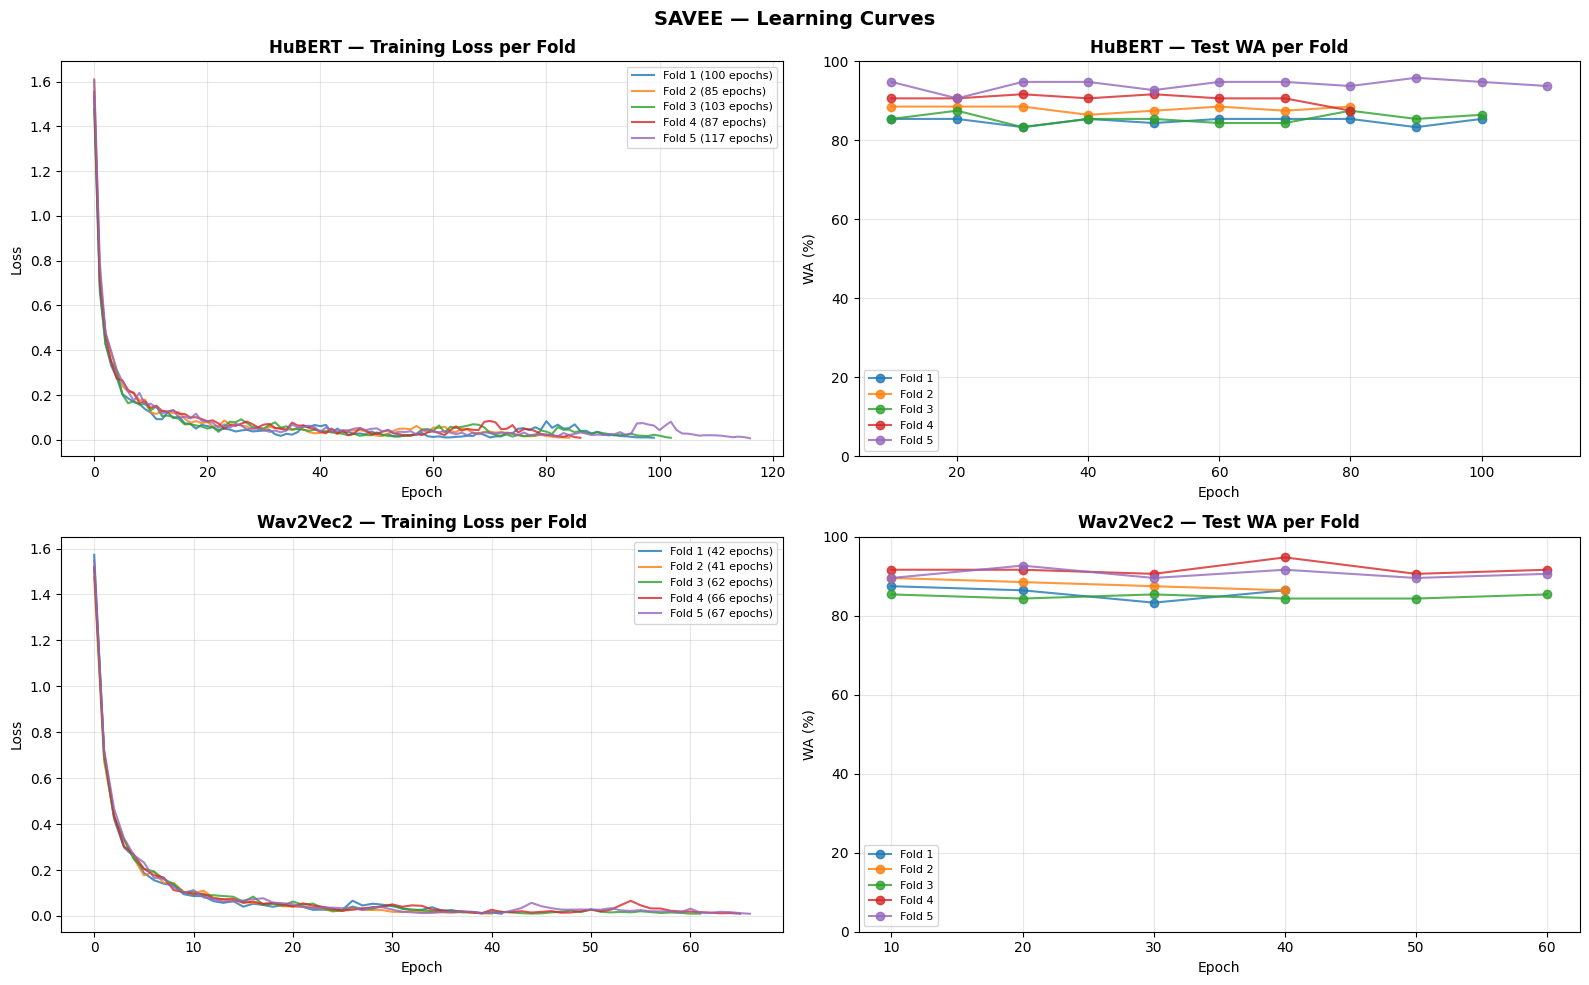

Learning curves saved


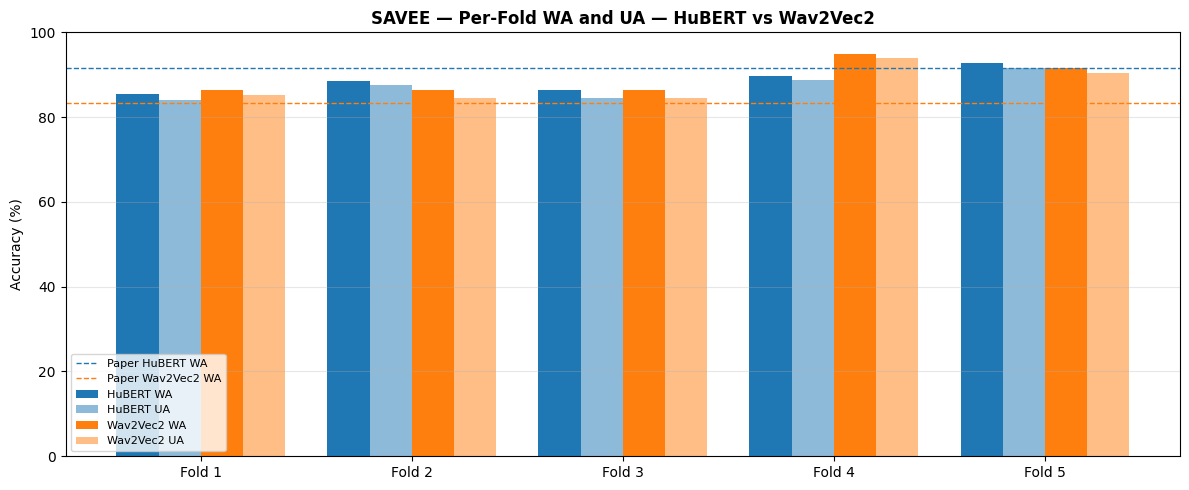

Per-fold performance chart saved


In [92]:
def plot_learning_curves(results, ax_loss, ax_wa):
    model_name = results['model_name']
    colors     = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, h in enumerate(results['history']):
        ax_loss.plot(
            h['losses'],
            color = colors[i],
            alpha = 0.8,
            label = f"Fold {h['fold']} ({h['epochs']} epochs)",
        )
        wa_epochs = [(e+1)*10 for e in range(len(h['was']))]
        ax_wa.plot(
            wa_epochs,
            h['was'],
            color  = colors[i],
            marker = 'o',
            alpha  = 0.8,
            label  = f"Fold {h['fold']}",
        )

    ax_loss.set_title(f"{model_name} — Training Loss per Fold", fontweight='bold')
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    ax_wa.set_title(f"{model_name} — Test WA per Fold", fontweight='bold')
    ax_wa.set_xlabel("Epoch")
    ax_wa.set_ylabel("WA (%)")
    ax_wa.set_ylim(0, 100)
    ax_wa.legend(fontsize=8)
    ax_wa.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_learning_curves(results_hubert,  axes[0][0], axes[0][1])
plot_learning_curves(results_wav2vec, axes[1][0], axes[1][1])

plt.suptitle(f"SAVEE — Learning Curves", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_PATH}ser_{DATASET_NAME.lower()}_learning_curves.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Learning curves saved")


# ── per-fold bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x      = np.arange(N_FOLDS)
width  = 0.2

ax.bar(x - width*1.5, results_hubert['fold_wa'],  width, label='HuBERT WA',   color='#1f77b4')
ax.bar(x - width*0.5, results_hubert['fold_ua'],  width, label='HuBERT UA',   color='#1f77b4', alpha=0.5)
ax.bar(x + width*0.5, results_wav2vec['fold_wa'], width, label='Wav2Vec2 WA', color='#ff7f0e')
ax.bar(x + width*1.5, results_wav2vec['fold_ua'], width, label='Wav2Vec2 UA', color='#ff7f0e', alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in range(N_FOLDS)])
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.set_title(f"SAVEE — Per-Fold WA and UA — HuBERT vs Wav2Vec2", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# add paper reference lines
ax.axhline(91.66, color='#1f77b4', linestyle='--', linewidth=1, label='Paper HuBERT WA')
ax.axhline(83.34, color='#ff7f0e', linestyle='--', linewidth=1, label='Paper Wav2Vec2 WA')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_PATH}ser_{DATASET_NAME.lower()}_per_fold_performance.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Per-fold performance chart saved")